In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fact_viajes = pd.read_csv("fact_viajes.csv")

fact_viajes.head()


FileNotFoundError: [Errno 2] No such file or directory: 'fact_viajes.csv'

In [4]:
import os

print(os.getcwd())


c:\Users\msalo\Desktop\DAW\Proyecto Fin de Master Data\metrobus_dataset


In [5]:
import os

for archivo in os.listdir():
    print(archivo)

.vscode
01_eda.ipynb
metrobus_dataset


In [6]:
fact_viajes = pd.read_csv("metrobus_dataset/fact_viajes.csv")

fact_viajes.head()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


In [7]:
ruta = "metrobus_dataset/"

fact_viajes = pd.read_csv(ruta + "fact_viajes.csv")
fact_incidencias = pd.read_csv(ruta + "fact_incidencias.csv")
fact_mantenimiento = pd.read_csv(ruta + "fact_mantenimiento.csv")

dim_conductor = pd.read_csv(ruta + "dim_conductor.csv")
dim_depot = pd.read_csv(ruta + "dim_depot.csv")
dim_linea = pd.read_csv(ruta + "dim_linea.csv")
dim_parada = pd.read_csv(ruta + "dim_parada.csv")
dim_tarifa = pd.read_csv(ruta + "dim_tarifa.csv")
dim_vehiculo = pd.read_csv(ruta + "dim_vehiculo.csv")

print("Datos cargados correctamente")

Datos cargados correctamente


In [8]:
tablas = {
    "fact_viajes": fact_viajes,
    "fact_incidencias": fact_incidencias,
    "fact_mantenimiento": fact_mantenimiento,
    "dim_conductor": dim_conductor,
    "dim_depot": dim_depot,
    "dim_linea": dim_linea,
    "dim_parada": dim_parada,
    "dim_tarifa": dim_tarifa,
    "dim_vehiculo": dim_vehiculo
}

for nombre, df in tablas.items():
    print(f"{nombre}: {df.shape}")

fact_viajes: (50000, 24)
fact_incidencias: (4000, 16)
fact_mantenimiento: (876, 15)
dim_conductor: (30, 10)
dim_depot: (3, 6)
dim_linea: (10, 7)
dim_parada: (120, 10)
dim_tarifa: (9, 6)
dim_vehiculo: (45, 12)


Se realiza la carga de las tablas. 
se comprueba que las tablas se han cargado de forma correcta, la tabla con mas informacion es la tabbla de viajes con 50000 registros

In [9]:
for nombre, df in tablas.items():
    print("\n" + "="*50)
    print(nombre)
    print("="*50)
    print(df.info())


fact_viajes
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   viaje_id                50000 non-null  int64  
 1   linea_id                50000 non-null  int64  
 2   vehiculo_id             50000 non-null  int64  
 3   conductor_id            50000 non-null  int64  
 4   parada_origen_id        50000 non-null  int64  
 5   parada_destino_id       50000 non-null  int64  
 6   fecha                   50000 non-null  str    
 7   anno                    50000 non-null  int64  
 8   mes                     50000 non-null  int64  
 9   dia_semana              50000 non-null  str    
 10  es_festivo              50000 non-null  bool   
 11  franja_horaria          50000 non-null  str    
 12  hora_salida_prog        50000 non-null  str    
 13  hora_salida_real        50000 non-null  str    
 14  hora_llegada_real       50000 non-nu

In [10]:
for nombre, df in tablas.items():
    print("\n" + "="*60)
    print(nombre)
    print("="*60)

    resumen = pd.DataFrame({
        "Tipo": df.dtypes,
        "Nulos": df.isnull().sum(),
        "% Nulos": round(df.isnull().mean()*100, 2)
    })

    display(resumen)
    


fact_viajes


,Tipo,Nulos,% Nulos
viaje_id,int64,0,0.00
linea_id,int64,0,0.00
vehiculo_id,int64,0,0.00
conductor_id,int64,0,0.00
parada_origen_id,int64,0,0.00
parada_destino_id,int64,0,0.00
fecha,str,0,0.00
anno,int64,0,0.00
mes,int64,0,0.00
dia_semana,str,0,0.00



fact_incidencias


,Tipo,Nulos,% Nulos
incidencia_id,int64,0,0.0
viaje_id,int64,0,0.0
vehiculo_id,int64,0,0.0
conductor_id,int64,0,0.0
linea_id,int64,0,0.0
fecha,str,0,0.0
anno,int64,0,0.0
mes,int64,0,0.0
hora_incidencia,str,0,0.0
tipo_incidencia,str,0,0.0



fact_mantenimiento


...

,Tipo,Nulos,% Nulos
parada_id,int64,0,0.00
nombre_parada,str,0,0.00
barrio,str,0,0.00
tipo,str,0,0.00
latitud,float64,1,0.83
longitud,float64,0,0.00
accesible_silla,object,1,0.83
marquesina,bool,0,0.00
panel_informacion,bool,0,0.00
activa,bool,0,0.00



dim_tarifa


,Tipo,Nulos,% Nulos
tarifa_id,int64,0,0.0
tipo_titulo,str,0,0.0
categoria,str,0,0.0
precio_eur,float64,0,0.0
es_abono,bool,0,0.0
bonificado,bool,0,0.0



dim_vehiculo


,Tipo,Nulos,% Nulos
vehiculo_id,int64,0,0.00
matricula,str,0,0.00
modelo,str,0,0.00
combustible,str,1,2.22
capacidad_sentados,int64,0,0.00
capacidad_total,int64,0,0.00
anno_fabricacion,int64,0,0.00
anno_incorporacion,int64,0,0.00
km_totales,int64,0,0.00
depot_id,int64,0,0.00


In [11]:
fact_viajes.head()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


In [12]:
for nombre, df in tablas.items():

    nulos = df.isnull().sum()

    porcentaje = round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )

    resumen = pd.DataFrame({
        "Nulos": nulos,
        "Porcentaje": porcentaje
    })

    resumen = resumen[resumen["Nulos"] > 0]

    if len(resumen) > 0:
        print(f"\n{nombre}")
        display(resumen)


fact_viajes


,Nulos,Porcentaje
pasajeros_subidos,40,0.08
consumo,1065,2.13



fact_mantenimiento


,Nulos,Porcentaje
categoria,15,1.71



dim_conductor


,Nulos,Porcentaje
antiguedad_anos,1,3.33



dim_parada


,Nulos,Porcentaje
latitud,1,0.83
accesible_silla,1,0.83



dim_vehiculo


,Nulos,Porcentaje
combustible,1,2.22


Despues de realizar un analisis de los datos se ha podido comprobar:
- La tabla con mas valores nulos es fact_viajes
- Faltan datos en consumo, antiguedad, acesibilidad, latitud y combustible

In [14]:
fact_viajes[fact_viajes["ocupacion_pct"] > 1]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id


In [15]:
fact_viajes[fact_viajes["pasajeros_subidos"] < 0]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id


In [16]:
fact_viajes[fact_viajes["consumo"] < 0]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id


In [17]:
fact_viajes[fact_viajes["km_recorridos"] < 0]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id


In [18]:
for nombre, df in tablas.items():
    duplicados = df.duplicated().sum()
    print(f"{nombre}: {duplicados} registros duplicados")

fact_viajes: 0 registros duplicados
fact_incidencias: 0 registros duplicados
fact_mantenimiento: 0 registros duplicados
dim_conductor: 0 registros duplicados
dim_depot: 0 registros duplicados
dim_linea: 0 registros duplicados
dim_parada: 0 registros duplicados
dim_tarifa: 0 registros duplicados
dim_vehiculo: 0 registros duplicados


In [19]:
dim_conductor["conductor_id"].duplicated().sum()

np.int64(0)

In [20]:
dim_vehiculo["vehiculo_id"].duplicated().sum()
dim_linea["linea_id"].duplicated().sum()
dim_parada["parada_id"].duplicated().sum()
dim_tarifa["tarifa_id"].duplicated().sum()
dim_depot["depot_id"].duplicated().sum()

np.int64(0)

In [21]:
set(fact_viajes["vehiculo_id"]) - set(dim_vehiculo["vehiculo_id"])

set()

In [22]:
set(fact_viajes["conductor_id"]) - set(dim_conductor["conductor_id"])

set(fact_viajes["linea_id"]) - set(dim_linea["linea_id"])

set()

In [23]:
pd.to_datetime(fact_viajes["fecha"], errors="coerce").isnull().sum()

np.int64(0)

In [24]:
fact_viajes["viaje_completado"].value_counts()

viaje_completado
True     49027
False      973
Name: count, dtype: int64

In [25]:
fact_viajes[
    fact_viajes["viaje_completado"] == False
]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
52,53,6,12,26,37,95,2022-05-28,2022,5,Saturday,...,14:14,0,84,68.0,0.531,23.5,20.04,False,8.43,3
78,79,8,38,24,7,115,2022-03-31,2022,3,Thursday,...,17:12,2,50,11.0,0.085,12.6,9.74,False,12.60,4
111,112,4,29,1,27,105,2022-03-06,2022,3,Sunday,...,16:42,0,52,23.0,0.184,14.1,6.88,False,8.78,5
144,145,10,20,6,8,102,2023-03-21,2023,3,Tuesday,...,00:59,18,81,66.0,0.528,15.0,12.93,False,5.62,8
196,197,8,30,2,9,79,2022-02-03,2022,2,Thursday,...,08:14,9,55,122.0,0.953,12.6,11.02,False,3.62,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49761,49762,9,35,7,13,95,2024-01-29,2024,1,Monday,...,19:21,3,98,96.0,0.768,19.8,8.35,False,3.45,3
49884,49885,6,32,18,12,104,2023-04-30,2023,4,Sunday,...,21:09,18,101,96.0,0.750,23.5,19.11,False,8.24,5
49901,49902,5,7,7,26,60,2023-08-27,2023,8,Sunday,...,22:53,2,31,36.0,0.277,7.3,5.41,False,6.46,2
49907,49908,1,13,13,34,54,2023-03-28,2023,3,Tuesday,...,20:59,15,64,110.0,0.611,18.4,14.06,False,4.56,4


despues de realizar varios analisis para comprobar errores evidentes en los datos se ha podido ver que no existen. 
Se comprobo:
- Ocupaciones superiores al total
- Valores negativos de pasajeros transportados
- consumos negativos
- kilometros negativos
- registro duplicados...
En todos ellos no se encontro ninguna inconsistencia en los datos

Cuando se realizo el estado de finalizacion de los viajes se observo que muchos de los viajes aparecen como no finalizados, este dato puede ser de interes para un posterior analisis.
- 


In [26]:
fact_viajes["viaje_completado"].value_counts(normalize=True) * 100

viaje_completado
True     98.054
False     1.946
Name: proportion, dtype: float64

In [27]:
fact_viajes[
    fact_viajes["viaje_completado"] == False
][[
    "linea_id",
    "retraso_salida_min",
    "ocupacion_pct",
    "km_programados",
    "km_recorridos"
]].describe()

,linea_id,retraso_salida_min,ocupacion_pct,km_programados,km_recorridos
count,973.000000,973.000000,973.000000,973.000000,973.000000
mean,5.535457,4.007194,0.456098,13.517780,8.165098
std,2.819689,6.472079,0.264139,4.765268,3.876078
min,1.000000,-99.000000,0.008000,7.300000,2.200000
25%,3.000000,1.000000,0.223000,9.700000,5.160000
50%,5.000000,2.000000,0.431000,12.600000,7.500000
75%,8.000000,5.000000,0.692000,15.000000,10.300000
max,10.000000,39.000000,0.992000,23.500000,20.980000


In [28]:
fact_viajes.groupby("viaje_completado")[
    ["retraso_salida_min","ocupacion_pct","km_recorridos"]
].mean()

,retraso_salida_min,ocupacion_pct,km_recorridos
viaje_completado,,,
False,4.007194,0.456098,8.165098
True,3.889897,0.455347,14.024480


In [29]:
fact_viajes["retraso_salida_min"].describe()

count    50000.00000
mean         3.89218
std          6.76309
min        -99.00000
25%          1.00000
50%          2.00000
75%          5.00000
max         50.00000
Name: retraso_salida_min, dtype: float64

In [30]:
fact_viajes[
    fact_viajes["retraso_salida_min"] < -30
][[
    "viaje_id",
    "fecha",
    "linea_id",
    "retraso_salida_min"
]]

,viaje_id,fecha,linea_id,retraso_salida_min
577,578,2023-02-14,4,-99
741,742,2022-01-23,9,-99
1857,1858,2023-11-21,8,-99
2411,2412,2024-09-26,3,-99
2910,2911,2022-05-28,9,-99
...,...,...,...,...
44373,44374,2024-07-22,8,-99
45117,45118,2023-01-27,9,-99
46741,46742,2023-01-08,10,-99
47368,47369,2023-09-08,2,-99


In [31]:
fact_viajes[fact_viajes["retraso_salida_min"] == -99].shape[0]

80

In [32]:
(
    fact_viajes["retraso_salida_min"] == -99
).mean() * 100

np.float64(0.16)

Durante el analisis se realizo un analisis de los retrasos en las salidas y se pudo observar que habian salidas de -99 minutos que representan el 0.16% de los viajes. Debido a los 99 minutos que los autobuses estan saliendo antes, puede considerarse un codigo para representar errores 

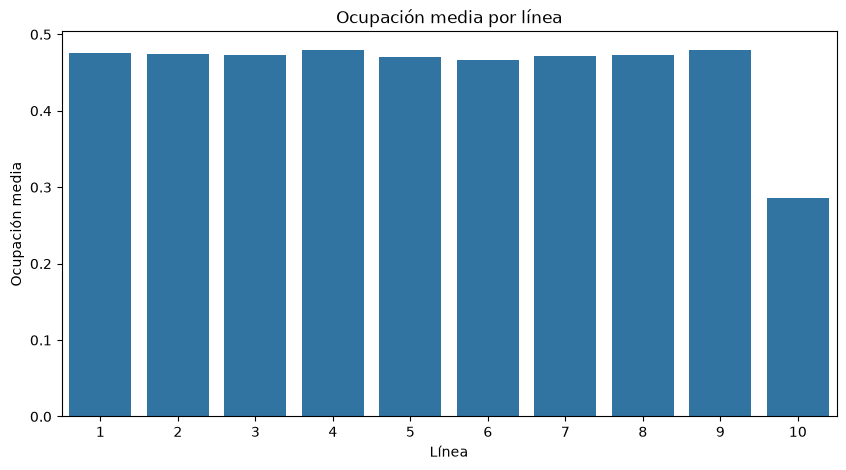

In [33]:
ocupacion_linea = (
    fact_viajes
    .groupby("linea_id")["ocupacion_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=ocupacion_linea.index,
    y=ocupacion_linea.values
)

plt.title("Ocupación media por línea")
plt.xlabel("Línea")
plt.ylabel("Ocupación media")
plt.show()

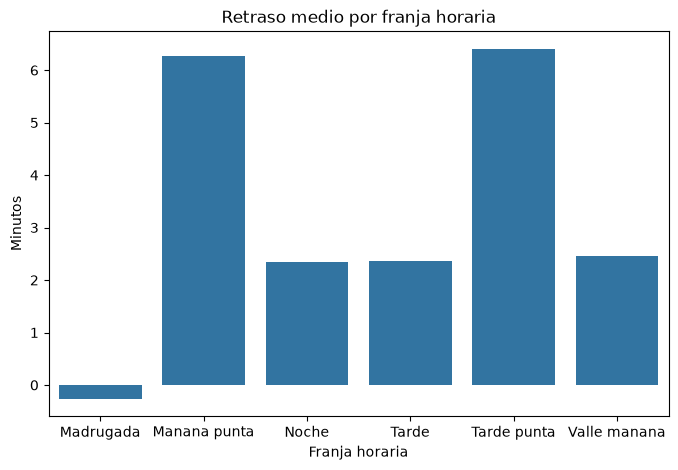

In [34]:
retrasos_franja = (
    fact_viajes
    .groupby("franja_horaria")["retraso_salida_min"]
    .mean()
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=retrasos_franja.index,
    y=retrasos_franja.values
)

plt.title("Retraso medio por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Minutos")
plt.show()

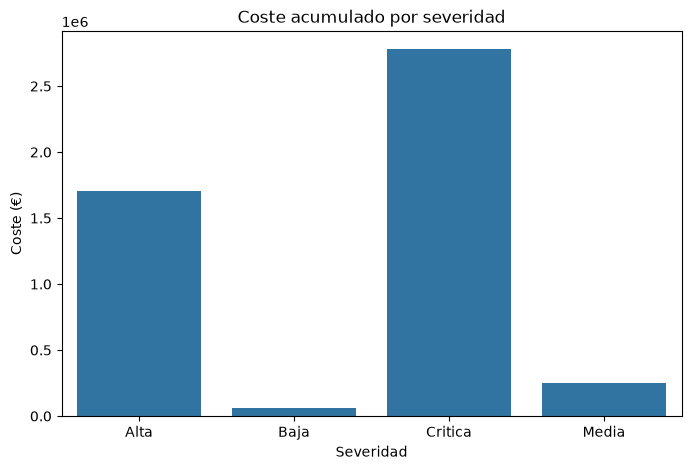

In [35]:
costes = (
    fact_incidencias
    .groupby("severidad")["coste_estimado_eur"]
    .sum()
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=costes.index,
    y=costes.values
)

plt.title("Coste acumulado por severidad")
plt.xlabel("Severidad")
plt.ylabel("Coste (€)")
plt.show()

Se ha analizado la ocupacion media de las lineas, pudiendo observar que la linea con menos demanda es la numero 10 lo cual puede indicar una menor demanda o demasiada oferta en determinados horarios. 

con respecto al retraso puede observarse que cuando mas se produce es en la hora punta de la mañana y de la tarde, siendo este comportamiento normal debido a que es cuando mas gente utiliza el transporte.

El ultimo análisis realizado ha sido del coste y puede observarse que aquellas incidencias clasificadas como alta y critica son las mas cara, por lo cual su imacto financiero es el mayor. 

Conclusiones:
Despues de una primera exploracion de los datos ha podido observarse que los datos presentan una buena estructura para un correcto analisis, no encontrandose registros duplicados, ni datos que afecten a la integridad de las tabalas.
Por el contrario, si se han detectado valores nulos en variables importantes.
Por ultimo se ha encontrado una anomalia relacionada con los retrasos en las salida, la cual habra que analizar y limpiar.
Todos los datos obtenidos en los graficos serviran de analisis en las siguientes fases del trabajo. 